### Imports

In [1]:
import json
import os
import pandas as pd

from utils_MS import *

# %load_ext autotime

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import plotly.graph_objects as go
import sys
import torch
import torch.nn.functional as F
import os.path as osp

%matplotlib inline
from IPython import display
from IPython.display import HTML
from matplotlib import animation

from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

from torch_geometric.datasets import KarateClub, Planetoid
from torch_geometric.data import Data
from torch import nn, optim, Tensor
from torch_geometric.utils import structured_negative_sampling, to_networkx
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn import LGConv, Node2Vec, GCNConv, GATv2Conv, SAGEConv
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout
import torch_geometric.transforms as T

from tqdm import tqdm

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import kneighbors_graph

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

In [7]:
# def run(params):

### Parameters

In [8]:
""" try:
    dir = os.path.dirname(os.path.abspath(__file__))
except:
    dir = os.getcwd()
print(dir) """

' try:\n    dir = os.path.dirname(os.path.abspath(__file__))\nexcept:\n    dir = os.getcwd()\nprint(dir) '

In [9]:
dict_dataset = {
    1: ["Mentos_2_process_NormalizationFiltered_format", ["Orange"]], # new mentos,  for Metabolomics
    2: ["deybis_filter_september_2br_3ar_format", ["SecoAmazonas"]],
    3: ["deybis_filter_december_2br_3ar_format", ["SecoAmazonas"]],
    4: ["deybis_filter_september_2br_10ar_format", ["SecoAmazonas"]],
    5: ["deybis_filter_december_2br_10ar_format", ["SecoAmazonas"]], # for Metabolomics
    6: ["deybis_filter_september_min_2br_3ar_format", ["SecoAmazonas"]],
    7: ["deybis_filter_december_min_2br_3ar_format", ["SecoAmazonas"]],
    8: ["vanessa_december_2br_3ar_format", ["SecoAmazonas"]],
    9: ["Pablo_2br_nar_format", ["AR"]],
    10: ["Pablo_2br_14ar_format", ["AR"]],
}
dataset = dict_dataset[9] # change
dataset

['Pablo_2br_nar_format', ['AR']]

In [10]:
params = {
    "exp": "exp0", # Change
    "methods": ["t-gae"], # ["vgae-base", "argva-base", "vgae-line", "dgi-tran", "t-gae"],
    "data_variations": ["none"],
    "has_transformation": True, # True or False
    "controls": dataset[1],
    "dimension": 64,
    "threshold_corr": 0.5,
    "threshold_log2": 0,
    "alpha": 0.05,
    "iterations": 1,
    "raw_data_file": dataset[0],
    "groups_id_no": ["Blank", "QC", "Std"],
    "sensitivity": False, # False: f1 (selectivity), True: f1 (selectivity), f2 (sensitivity)
    "obs": "",
    "seeds": [41, 42, 43, 44, 45, 46],
    
    "from": "python",
    "cuda": 0,
    "epochs": 100,
    "lr": 0.0001,
    "weight_decay": 1e-4,
    "patience": 10,
    "contamination": 0.1, # float in (0., 0.5)
    "n_jobs": 1, # -1 all
}

In [11]:
""" dir_path = "experiments/output"
res = sorted(os.listdir(dir_path))
n = len(res)
exp = "exp{}".format(n) """

exp = str(params["exp"])
exp

'exp0'

### Load dataset

In [12]:
# load dataset groups
if params["from"] == "python":
    df_raw = pd.read_csv("experiments/raw_data/{}.csv".format(params["raw_data_file"]), delimiter="|")
elif params["from"] == "drf":
    df_raw = pd.read_csv("{}".format(params["raw_data_file"]), delimiter="|") # from DRF
df_raw

,Alignment ID,Average Rt,Average Mz,Metabolite name,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,5439,1.0,732.79951,Unknown,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,5440,1.0,748.76437,Unknown,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,5441,1.0,794.79590,Unknown,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,5442,1.0,800.81295,Unknown,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


### Format dataset

In [13]:
# has transformation
""" columns_data = list(df_raw.columns)[4:]
if params["has_transformation"]:
    print("transformation")
    for column in columns_data:
        df_raw[column] = df_raw[column].apply(lambda x: 10**x)
df_raw """

' columns_data = list(df_raw.columns)[4:]\nif params["has_transformation"]:\n    print("transformation")\n    for column in columns_data:\n        df_raw[column] = df_raw[column].apply(lambda x: 10**x)\ndf_raw '

In [14]:
# concat
df_join_raw = pd.concat([
    df_raw.iloc[:, :]], axis=1)
df_join_raw.set_index("Alignment ID", inplace=True)
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
Alignment ID,,,,,,,,,,,,,,,,,,,,,
0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,1.0,732.79951,Unknown,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,1.0,748.76437,Unknown,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.0,794.79590,Unknown,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369


In [15]:
# split
df_join_raw = df_join_raw.rename_axis(None)
# df_join_raw = df_join_raw.iloc[:, 2:]
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,1.0,732.79951,Unknown,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,1.0,748.76437,Unknown,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.0,794.79590,Unknown,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,1.0,800.81295,Unknown,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,0.232784,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


In [16]:
# get metadata
df_join_raw_metadata = df_join_raw.iloc[:, :2]
df_join_raw_metadata

,Average Rt,Average Mz
0,1.0,69.99951
1,1.0,70.04025
2,1.0,70.04151
3,1.0,70.04908
4,1.0,70.06267
...,...,...
5439,1.0,732.79951
5440,1.0,748.76437
5441,1.0,794.79590
5442,1.0,800.81295


In [17]:
df_join_raw_intensity = df_join_raw.iloc[:, 3:]
df_join_raw_intensity

,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,AR_1.8,AR_1.9,AR_1.10,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,-1.137626,-0.902078,-0.767949,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,1.600685,1.835802,1.969684,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,0.384811,0.575840,0.684617,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,0.920234,1.144870,1.272785,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,0.674229,0.887961,1.006285,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,0.001144,0.120999,0.212084,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,-0.226744,0.036429,0.186288,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,0.080823,0.361589,0.471603,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,0.232784,0.328276,0.626443,0.796229,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


In [18]:
# get groups name
groups_id = []
for item in df_join_raw_intensity.columns.values:
    group_id = item.split("_")[0]
    groups_id.append(group_id)
print(groups_id)

['AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR

### Classification

#### Data preparation

In [19]:
df_join_raw_intensity

,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,AR_1.8,AR_1.9,AR_1.10,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,-1.137626,-0.902078,-0.767949,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,1.600685,1.835802,1.969684,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,0.384811,0.575840,0.684617,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,0.920234,1.144870,1.272785,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,0.674229,0.887961,1.006285,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,0.001144,0.120999,0.212084,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,-0.226744,0.036429,0.186288,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,0.080823,0.361589,0.471603,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,0.232784,0.328276,0.626443,0.796229,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


In [20]:
df_join_raw_intensity_t = df_join_raw_intensity.T
df_join_raw_intensity_t

,0,1,2,3,4,5,6,7,8,9,...,5434,5435,5436,5437,5438,5439,5440,5441,5442,5443
AR_1.1,0.575329,2.519698,0.580982,2.570505,1.157874,1.272133,2.620286,2.639902,2.650395,2.737571,...,1.646839,1.989872,-0.309330,1.237020,1.871359,2.214770,0.725796,1.651239,1.511482,1.942363
AR_1.2,-2.215760,0.524517,-0.489549,-0.107955,-0.151374,0.103413,0.382952,0.465804,0.413413,0.575501,...,0.054335,-0.076922,-2.002184,-0.302498,-0.263026,-0.588492,-1.431324,-1.204281,-1.036480,-1.792946
AR_1.3,-1.877019,0.862641,-0.214833,0.215094,0.127539,0.362454,0.635314,0.714628,0.672398,0.813973,...,0.420733,0.220670,-1.635126,0.011700,-0.036789,-0.389296,-1.052855,-0.800512,-0.607684,-1.446490
AR_1.4,-1.518844,1.220163,0.075646,0.556676,0.297939,0.636357,0.902154,0.977727,0.946242,1.066128,...,0.808151,0.535335,-1.247009,0.343924,0.202428,-0.178671,-0.652672,-0.373577,-0.154288,6.032124
AR_1.5,-1.398838,1.339951,0.172970,0.671123,0.422454,0.728129,0.991559,1.065879,1.037993,1.150612,...,0.937955,0.640763,-1.116970,0.455236,0.282577,-0.108101,-0.518591,-0.230533,-0.002378,-1.080157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PD_2.48,-1.078037,2.048076,0.532269,0.694677,1.147188,1.281281,1.483590,1.526765,1.490460,1.509782,...,1.417113,1.111133,-0.523850,0.964093,0.519408,0.169659,0.269194,0.376221,0.807407,-0.287301
PD_2.49,0.566607,2.197014,0.560055,2.494512,1.188020,1.317392,1.516478,1.557615,1.518535,1.539703,...,3.328193,1.233554,-0.440321,1.050329,0.665531,0.318208,0.431907,2.624637,0.923866,-0.141182
PD_2.50,-1.074093,2.063083,0.535142,0.701435,2.990083,3.036166,3.127255,3.199071,3.177941,3.193424,...,1.425000,1.124192,1.831967,2.777941,0.534716,0.184348,0.284983,0.391893,0.817754,-0.272872
PD_2.51,-1.041128,2.188817,0.559160,0.730124,1.187039,1.316454,1.515599,1.556713,1.517598,1.538771,...,1.515664,1.226387,-0.444683,1.048357,0.659959,0.310187,0.423283,0.511456,0.919121,-0.149082


In [21]:
print(len(groups_id), groups_id)

1248 ['AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR'

In [22]:
X = df_join_raw_intensity_t.values
X

array([[ 0.57532885,  2.51969796,  0.58098199, ...,  1.651239  ,
         1.51148168,  1.94236309],
       [-2.21575978,  0.52451716, -0.48954929, ..., -1.2042815 ,
        -1.03647972, -1.79294611],
       [-1.87701936,  0.86264111, -0.21483259, ..., -0.80051188,
        -0.6076844 , -1.44649002],
       ...,
       [-1.0740925 ,  2.06308315,  0.53514171, ...,  0.39189314,
         0.81775426, -0.27287199],
       [-1.04112818,  2.18881682,  0.55916018, ...,  0.51145602,
         0.91912126, -0.14908227],
       [-1.0767184 ,  2.05109001,  1.82090801, ...,  0.37936922,
         0.8100022 , -0.28440334]])

In [23]:
# Convertir a serie de categorías y obtener los códigos numéricos
y = pd.Series(groups_id).astype("category").cat.codes.values
y

array([0, 0, 0, ..., 8, 8, 8], dtype=int8)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# print(y_test)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit only on train
X_test = scaler.transform(X_test)        # only transform on test

#### Model selection and train

In [25]:
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 15),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5)
}


# Create a random forest classifier
model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
    model, param_distributions=param_dist,
    n_iter=10, cv=5, scoring="accuracy",
    n_jobs=-1, random_state=42)

# Select and train model
search = rand_search.fit(X_train, y_train)

# Create a variable for the best model
best_model = rand_search.best_estimator_

# Print the best hyperparameters
print("Best hyperparameters:",  rand_search.best_params_)

Best hyperparameters: {'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 413}


#### Evaluation

In [26]:
# Evaluation
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")
classification_rep = classification_report(y_test, y_pred, output_dict=False)

print("Accuracy: ", accuracy)
print("Recall: ", recall_macro)
print("F1-score: ", f1_macro)

print(classification_rep)

Accuracy:  0.676
Recall:  0.5146983087906009
F1-score:  0.5439049699486106
              precision    recall  f1-score   support

           0       0.72      1.00      0.84        92
           1       0.68      0.76      0.72        17
           2       0.52      0.69      0.59        16
           3       0.67      0.40      0.50         5
           4       1.00      0.17      0.29         6
           5       0.89      0.57      0.70        14
           6       0.44      0.33      0.38        12
           7       0.52      0.71      0.60        21
           8       1.00      0.57      0.73        21
           9       0.53      0.28      0.36        29
          10       0.60      0.18      0.27        17

    accuracy                           0.68       250
   macro avg       0.69      0.51      0.54       250
weighted avg       0.69      0.68      0.64       250



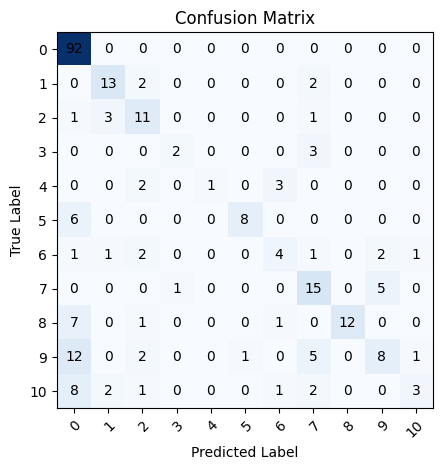

In [27]:
cm = confusion_matrix(y_test, y_pred)
class_names = best_model.classes_
tick_marks = np.arange(len(class_names))

plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
# plt.colorbar()
plt.xticks(tick_marks, class_names, rotation=45, ha="right", rotation_mode="anchor")
plt.yticks(tick_marks, class_names)

# Values inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            format(cm[i, j], "d"),
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Node classification

In [28]:
def visualize_(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

def visualize(h, color, class_names):
    z = TSNE(n_components=2, random_state=42).fit_transform(
        h.detach().cpu().numpy()
    )

    color = np.asarray(color)
    class_names = np.asarray(class_names)

    plt.figure(figsize=(10, 10))

    scatter = plt.scatter(
        z[:, 0],
        z[:, 1],
        c=color,
        cmap="tab20",
        s=70,
        alpha=0.8,
    )

    plt.xticks([])
    plt.yticks([])

    # Obtener una etiqueta por clase
    unique_classes = np.unique(color)
    handles = scatter.legend_elements()[0]

    labels = [
        class_names[color == c][0]
        for c in unique_classes
    ]

    plt.legend(
        handles,
        labels,
        title="Node types",
        loc="best"
    )

    plt.tight_layout()
    plt.show()
    
# Calculate accuracy
def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

In [29]:
import torch

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### Preprocessing

##### Option 1 (partial correlations)

In [ ]:
# Partial correlation

""" df_matrix = pg.pcorr(df_join_raw_intensity)
df_matrix """


from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
scaler = StandardScaler()

df_subgroup_scaled = scaler.fit_transform(df_join_raw_intensity)
lw = LedoitWolf()
lw.fit(df_subgroup_scaled)

# Matriz de covarianza regularizada
cov = lw.covariance_
std = np.sqrt(np.diag(cov))
corr = cov / np.outer(std, std)
df_matrix = pd.DataFrame(corr)
df_matrix

In [ ]:
# Edge list

threshold = np.percentile(np.abs(df_matrix), 3) # Important

df_weighted_edges = (df_matrix.where(np.triu(np.ones(df_matrix.shape), k=1).astype(bool)).stack())
df_weighted_edges = df_weighted_edges.dropna().to_frame()
df_weighted_edges.reset_index(inplace=True)
df_weighted_edges.columns = ["source", "target", "weight"]
df_weighted_edges = df_weighted_edges[df_weighted_edges["weight"].abs() >= threshold]
df_weighted_edges


In [ ]:
num_nodes = pd.concat([df_weighted_edges["source"], df_weighted_edges["target"]]).nunique()
num_nodes

##### Option 2 (K-NN)

In [30]:
df_join_raw_intensity

,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,AR_1.8,AR_1.9,AR_1.10,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,-1.137626,-0.902078,-0.767949,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,1.600685,1.835802,1.969684,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,0.384811,0.575840,0.684617,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,0.920234,1.144870,1.272785,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,0.674229,0.887961,1.006285,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,0.001144,0.120999,0.212084,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,-0.226744,0.036429,0.186288,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,0.080823,0.361589,0.471603,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,0.232784,0.328276,0.626443,0.796229,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


In [31]:
df_join_raw_intensity_t = df_join_raw_intensity.T
df_join_raw_intensity_t

,0,1,2,3,4,5,6,7,8,9,...,5434,5435,5436,5437,5438,5439,5440,5441,5442,5443
AR_1.1,0.575329,2.519698,0.580982,2.570505,1.157874,1.272133,2.620286,2.639902,2.650395,2.737571,...,1.646839,1.989872,-0.309330,1.237020,1.871359,2.214770,0.725796,1.651239,1.511482,1.942363
AR_1.2,-2.215760,0.524517,-0.489549,-0.107955,-0.151374,0.103413,0.382952,0.465804,0.413413,0.575501,...,0.054335,-0.076922,-2.002184,-0.302498,-0.263026,-0.588492,-1.431324,-1.204281,-1.036480,-1.792946
AR_1.3,-1.877019,0.862641,-0.214833,0.215094,0.127539,0.362454,0.635314,0.714628,0.672398,0.813973,...,0.420733,0.220670,-1.635126,0.011700,-0.036789,-0.389296,-1.052855,-0.800512,-0.607684,-1.446490
AR_1.4,-1.518844,1.220163,0.075646,0.556676,0.297939,0.636357,0.902154,0.977727,0.946242,1.066128,...,0.808151,0.535335,-1.247009,0.343924,0.202428,-0.178671,-0.652672,-0.373577,-0.154288,6.032124
AR_1.5,-1.398838,1.339951,0.172970,0.671123,0.422454,0.728129,0.991559,1.065879,1.037993,1.150612,...,0.937955,0.640763,-1.116970,0.455236,0.282577,-0.108101,-0.518591,-0.230533,-0.002378,-1.080157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PD_2.48,-1.078037,2.048076,0.532269,0.694677,1.147188,1.281281,1.483590,1.526765,1.490460,1.509782,...,1.417113,1.111133,-0.523850,0.964093,0.519408,0.169659,0.269194,0.376221,0.807407,-0.287301
PD_2.49,0.566607,2.197014,0.560055,2.494512,1.188020,1.317392,1.516478,1.557615,1.518535,1.539703,...,3.328193,1.233554,-0.440321,1.050329,0.665531,0.318208,0.431907,2.624637,0.923866,-0.141182
PD_2.50,-1.074093,2.063083,0.535142,0.701435,2.990083,3.036166,3.127255,3.199071,3.177941,3.193424,...,1.425000,1.124192,1.831967,2.777941,0.534716,0.184348,0.284983,0.391893,0.817754,-0.272872
PD_2.51,-1.041128,2.188817,0.559160,0.730124,1.187039,1.316454,1.515599,1.556713,1.517598,1.538771,...,1.515664,1.226387,-0.444683,1.048357,0.659959,0.310187,0.423283,0.511456,0.919121,-0.149082


In [32]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_join_raw_intensity_t.values)
X_scaled

array([[ 0.8198284 , -0.16041454, -1.16440078, ...,  0.15228228,
        -0.23376415,  1.42057987],
       [-3.02197289, -3.18621687, -3.01022798, ..., -2.46278743,
        -2.72685232, -2.40016117],
       [-2.55571274, -2.67343315, -2.53655704, ..., -2.09301747,
        -2.30729159, -2.04578114],
       ...,
       [-1.45052196, -0.85289623, -1.24343932, ..., -1.00101962,
        -0.91255137, -0.84532079],
       [-1.40514812, -0.66221415, -1.20202629, ..., -0.8915246 ,
        -0.81336743, -0.71869982],
       [-1.45413638, -0.87108449,  0.97349956, ..., -1.01248895,
        -0.92013648, -0.85711587]])

In [33]:
# similarity = cosine_similarity(X_scaled)
# similarity

In [34]:
# Similarity matrix

k = 10 # Change

A = kneighbors_graph(
    X_scaled,
    n_neighbors=k,
    metric="cosine",
    mode="distance",
    include_self=False
)
A

<1248x1248 sparse matrix of type '<class 'numpy.float64'>'
	with 12480 stored elements in Compressed Sparse Row format>

In [35]:
# Edge list

edges = []

n = A.shape[0]

for i in range(n):
    for j in range(i + 1, n):      # Solo parte superior (grafo no dirigido)
        if A[i, j] != 0:
            edges.append((i, j, A[i, j]))

print(edges)

df_weighted_edges = pd.DataFrame(edges, columns=["source", "target", "weight"])
df_weighted_edges

[(0, 102, 0.5393931152800497), (0, 193, 0.5227225885463908), (0, 210, 0.5216149029141322), (0, 244, 0.5159342758288883), (0, 414, 0.5422252729377454), (0, 627, 0.5503380861338403), (0, 632, 0.5322832024347343), (0, 708, 0.5300112754782806), (0, 758, 0.4693770931089213), (0, 761, 0.5369767426678542), (1, 2, 0.390260571468212), (1, 3, 0.38998162202265707), (1, 4, 0.4015025273870665), (1, 6, 0.4911723975302801), (1, 152, 0.49682209355938156), (1, 155, 0.4951319336482055), (1, 178, 0.4964149492440415), (1, 623, 0.48500838596554585), (1, 627, 0.47556073189752635), (1, 794, 0.4933910108035655), (2, 3, 0.3851816343346215), (2, 4, 0.46909897503722187), (2, 5, 0.4716248262175957), (2, 6, 0.47482553969517594), (2, 7, 0.4762204195271871), (2, 8, 0.5813797185515468), (2, 622, 0.5189281731172073), (2, 794, 0.4385278947071535), (2, 795, 0.5547252874011602), (3, 4, 0.3458845443924219), (3, 5, 0.5044023978749856), (3, 6, 0.4434614791336481), (3, 7, 0.5129547176266546), (3, 8, 0.53582378951551), (3, 62

,source,target,weight
0,0,102,0.539393
1,0,193,0.522723
2,0,210,0.521615
3,0,244,0.515934
4,0,414,0.542225
...,...,...,...
6197,1239,1245,0.419529
6198,1241,1245,0.429294
6199,1242,1243,0.432938
6200,1242,1246,0.445804


#### Data preparation

In [41]:
df_weighted_edges

,source,target,weight
0,0,102,0.539393
1,0,193,0.522723
2,0,210,0.521615
3,0,244,0.515934
4,0,414,0.542225
...,...,...,...
6197,1239,1245,0.419529
6198,1241,1245,0.429294
6199,1242,1243,0.432938
6200,1242,1246,0.445804


In [42]:
edge_index = torch.tensor(df_weighted_edges.iloc[:, [0, 1]].values, dtype=torch.long)

data = Data(edge_index=edge_index.t().contiguous())

num_nodes = data.num_nodes
x = torch.eye(num_nodes, dtype=torch.float)
data.x = x

y = torch.tensor(pd.Series(groups_id).astype("category").cat.codes.values, dtype=torch.long)
data.y = y

# 2. Obtener los índices de todos los nodos en formato numpy
node_indices = torch.arange(num_nodes).numpy()
labels = data.y.numpy()

# 3. Dividir los índices usando sklearn (80% entrenamiento, 20% prueba)
# Puedes usar "stratify=labels" si quieres mantener la proporción de clases
train_idx, test_idx = train_test_split(
    node_indices, 
    test_size=0.2, 
    random_state=42, 
    stratify=labels
)

# 4. Crear las máscaras booleanas vacías (en falso)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# 5. Cambiar a True las posiciones correspondientes a cada conjunto
train_mask[train_idx] = True
test_mask[test_idx] = True

# 6. Asignar las máscaras al objeto Data de PyTorch Geometric
data.train_mask = train_mask
data.test_mask = test_mask
data

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_geometric/data/data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])


Data(edge_index=[2, 6202], x=[1248, 1248], y=[1248], train_mask=[1248], test_mask=[1248])

In [43]:
print(data)
print()

# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Data(edge_index=[2, 6202], x=[1248, 1248], y=[1248], train_mask=[1248], test_mask=[1248])

Number of nodes: 1248
Number of edges: 6202
Average node degree: 4.97
Number of training nodes: 998
Training node label rate: 0.80
Contains isolated nodes: False
Contains self-loops: False
Is undirected: False


In [44]:
transform = T.Compose([T.ToUndirected()])#, T.AddSelfLoops()])
data = transform(data) 

print(data)
print()

# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Data(edge_index=[2, 12404], x=[1248, 1248], y=[1248], train_mask=[1248], test_mask=[1248])

Number of nodes: 1248
Number of edges: 12404
Average node degree: 9.94
Number of training nodes: 998
Training node label rate: 0.80
Contains isolated nodes: False
Contains self-loops: False
Is undirected: True


In [45]:
num_features = data.x.size(-1)

# 2. Obtener el número de clases (valores únicos en el tensor y)
if data.y.dim() <= 1:
    # Para clasificación de nodos o grafos con etiquetas discretas
    num_classes = int(data.y.max()) + 1
else:
    # Para etiquetas representadas en formato one-hot o multi-label
    num_classes = data.y.size(-1)

print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")

Number of features: 1248
Number of classes: 11


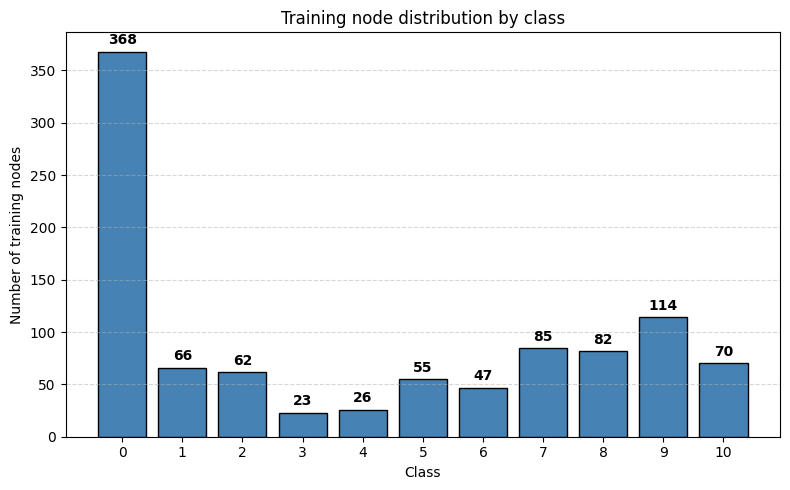

In [84]:
# Número de nodos por clase en el conjunto de entrenamiento
unique, counts = torch.unique(
    data.y[data.train_mask],
    return_counts=True
)

classes = unique.cpu().numpy()
counts = counts.cpu().numpy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    classes.astype(str),
    counts,
    color="steelblue",
    edgecolor="black"
)

# Mostrar el número de nodos sobre cada barra
plt.bar_label(
    bars,
    fmt="%d",
    padding=3,
    fontsize=10,
    fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Number of training nodes")
plt.title("Training node distribution by class")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### GCN

In [70]:
# Define GCN

class GCN(torch.nn.Module):
    def __init__(self, num_features, dim_h, num_classes):
        super(GCN, self).__init__()
        torch.manual_seed(42)
        self.conv1 = GCNConv(num_features, 1024)
        self.conv2 = GCNConv(1024, 128)
        self.conv3 = GCNConv(128, dim_h)
        self.classifier = Linear(dim_h, num_classes)

    def forward(self, x, edge_index):
        # Node embeddings
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv3(h, edge_index)
        z = h.relu()  # final GNN embedding space

        # Prediction head: linear classifier
        out = self.classifier(z)

        return out, z

# Hyperparameters
dimension = 128 # dimension of node embeddings
number_features = num_features # dimension of node features
number_classes = num_classes # number of classes

model = GCN(num_features=number_features, dim_h=dimension, num_classes=number_classes)
print(model)

GCN(
  (conv1): GCNConv(1248, 1024)
  (conv2): GCNConv(1024, 128)
  (conv3): GCNConv(128, 128)
  (classifier): Linear(in_features=128, out_features=11, bias=True)
)


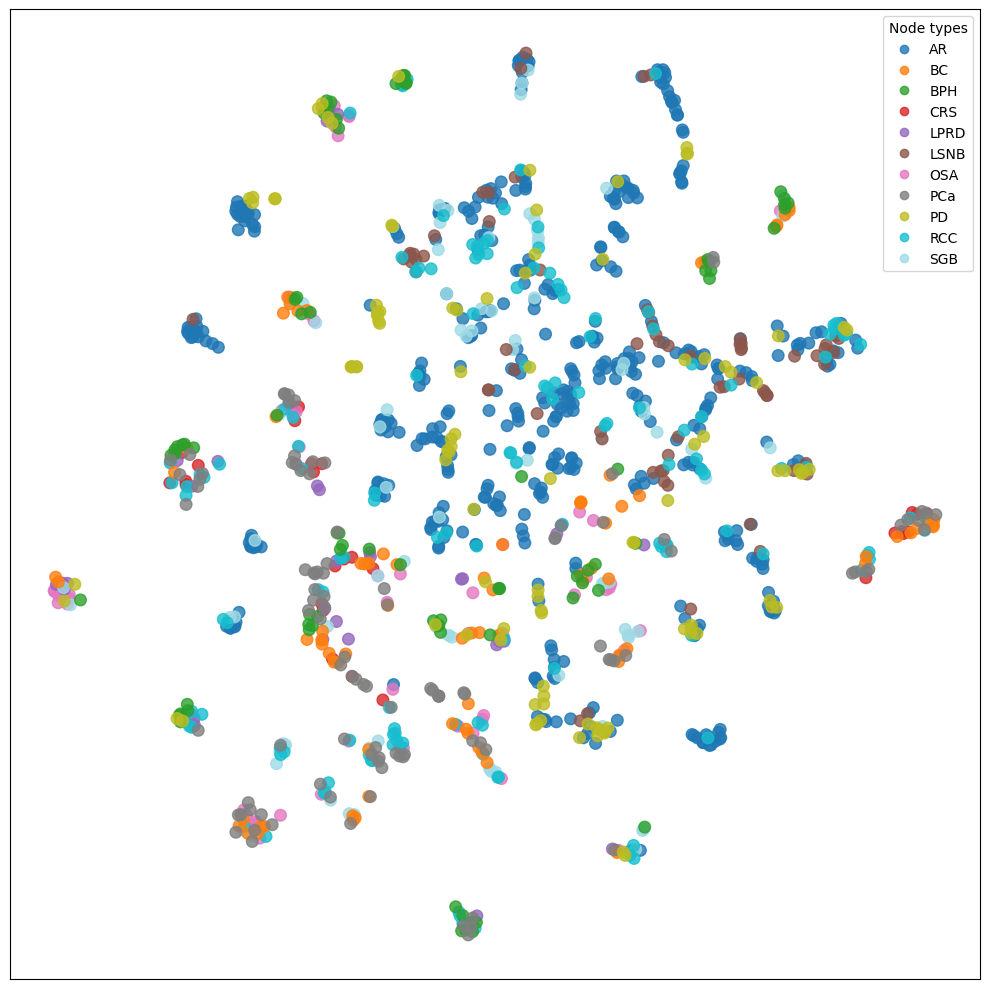

In [71]:
# Vizualization
model.eval()
out, z = model(data.x, data.edge_index)

visualize(z, data.y, groups_id)

In [72]:
# Train

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#, weight_decay=5e-4)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []
epochs = 1000

# Training loop
pbar = tqdm(range(1, epochs + 1))
for epoch in pbar:
    # Mode train
    model.train()
    
    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    out, z = model(data.x, data.edge_index)

    # Calculate loss function
    # loss = criterion(out, data.y)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    # Calculate accuracy
    acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    # Store data for animations
    embeddings.append(z)
    losses.append(loss.item())
    accuracies.append(acc)
    outputs.append(out.argmax(dim=1))

    # Print metrics
    pbar.set_description(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%")

    # Print metrics every 10 epochs
    """ if epoch % 10 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%") """

Epoch   2 | Loss: 2.42 | Acc: 2.61%:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1000 | Loss: 0.20 | Acc: 92.48%: 100%|██████████| 1000/1000 [00:26<00:00, 37.89it/s]


In [73]:
# Model evaluation
model.eval()
out, z = model(data.x, data.edge_index)
acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
print(f"Acc: {acc*100:.2f}%")

Acc: 48.80%


In [74]:
# Get node embeddings
print(z.shape)
z

torch.Size([1248, 128])


tensor([[1.0637, 0.0000, 5.4768,  ..., 0.4700, 6.7176, 0.3962],
        [0.7418, 0.0000, 4.4118,  ..., 0.1563, 5.7849, 0.6244],
        [0.0000, 0.0000, 2.6017,  ..., 0.0000, 4.4417, 1.7919],
        ...,
        [2.4622, 0.0000, 3.3927,  ..., 4.2939, 0.1780, 0.0000],
        [1.3848, 0.0000, 4.8780,  ..., 1.0998, 4.3284, 0.2791],
        [2.0899, 0.0000, 3.2547,  ..., 3.1639, 2.9478, 0.4295]],
       grad_fn=<ReluBackward0>)

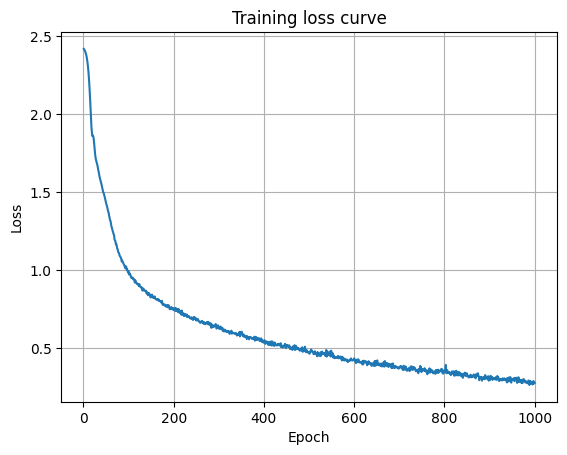

In [51]:
# Plot loss curve
plt.figure()
plt.plot(range(1, epochs + 1), losses, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training loss curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

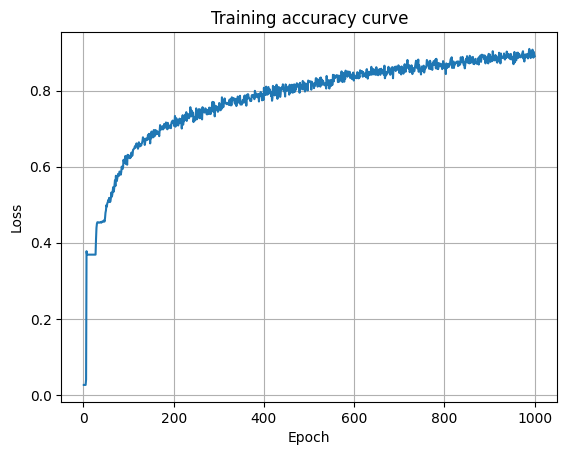

In [52]:
# Plot accuracy curve
plt.figure()
plt.plot(range(1, epochs + 1), accuracies, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training accuracy curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

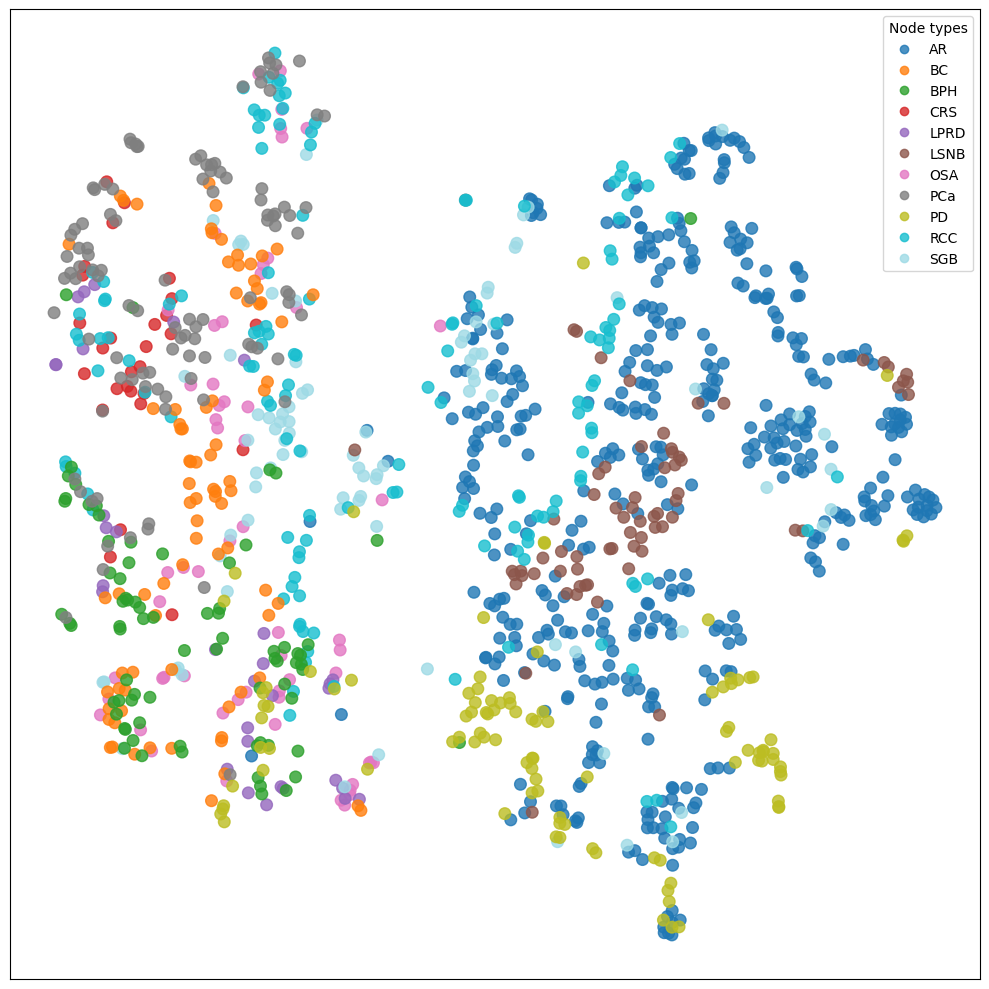

In [75]:
visualize(z, data.y, groups_id)

#### GAT

In [ ]:
# Define GAT
class GAT(torch.nn.Module):
    def __init__(self, num_features, dim_h, num_classes, heads=1):
        super(GAT, self).__init__()
        torch.manual_seed(42)
        # GAT layers
        """ self.conv1 = GATv2Conv(num_features, 512, heads=heads)
        self.conv2 = GATv2Conv(512 * heads, 64, heads=heads)
        self.conv3 = GATv2Conv(64 * heads, dim_h, heads=1) """
        
        """ self.conv1 = GATv2Conv(num_features, 64, heads=4)
        self.conv2 = GATv2Conv(64 * 4, 64, heads=4)
        self.conv3 = GATv2Conv(64 * 4, dim_h, heads=1) """
        
        self.conv1 = GATv2Conv(
            num_features,
            64,
            heads=4,
            dropout=0.6
        )

        self.conv2 = GATv2Conv(
            64 * 4,
            dim_h,
            heads=1,
            concat=False,
            dropout=0.6
        )
        
        # Prediction head
        self.classifier = Linear(dim_h, num_classes)

    def forward(self, x, edge_index):
        # Node embeddings
        """ h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv3(h, edge_index)
        z = h.relu()  # final GNN embedding space """
        
        """ h = self.conv1(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv2(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        z = self.conv3(h, edge_index) """
        
        """ x = F.dropout(x, 0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, 0.6, training=self.training)
        z = self.conv2(x, edge_index) """
        
        h = self.conv1(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training=self.training)
        h = self.conv2(h, edge_index)
        z = F.elu(h)
        
        # Prediction head: linear classifier
        out = self.classifier(z)
        return out, z

# Hyperparameters
dimension = 64 # node embedding dimension d'
num_features = num_features # input feature dimension d
num_classes = num_classes # number of output classes |Y|
num_heads = 2 # number of attention heads K

# Model instantiation
model = GAT(
    num_features = num_features,
    dim_h        = dimension,
    num_classes  = num_classes,
    heads        = num_heads
)
print(model)

GAT(
  (conv1): GATv2Conv(1248, 64, heads=4)
  (conv2): GATv2Conv(256, 64, heads=1)
  (classifier): Linear(in_features=64, out_features=11, bias=True)
)


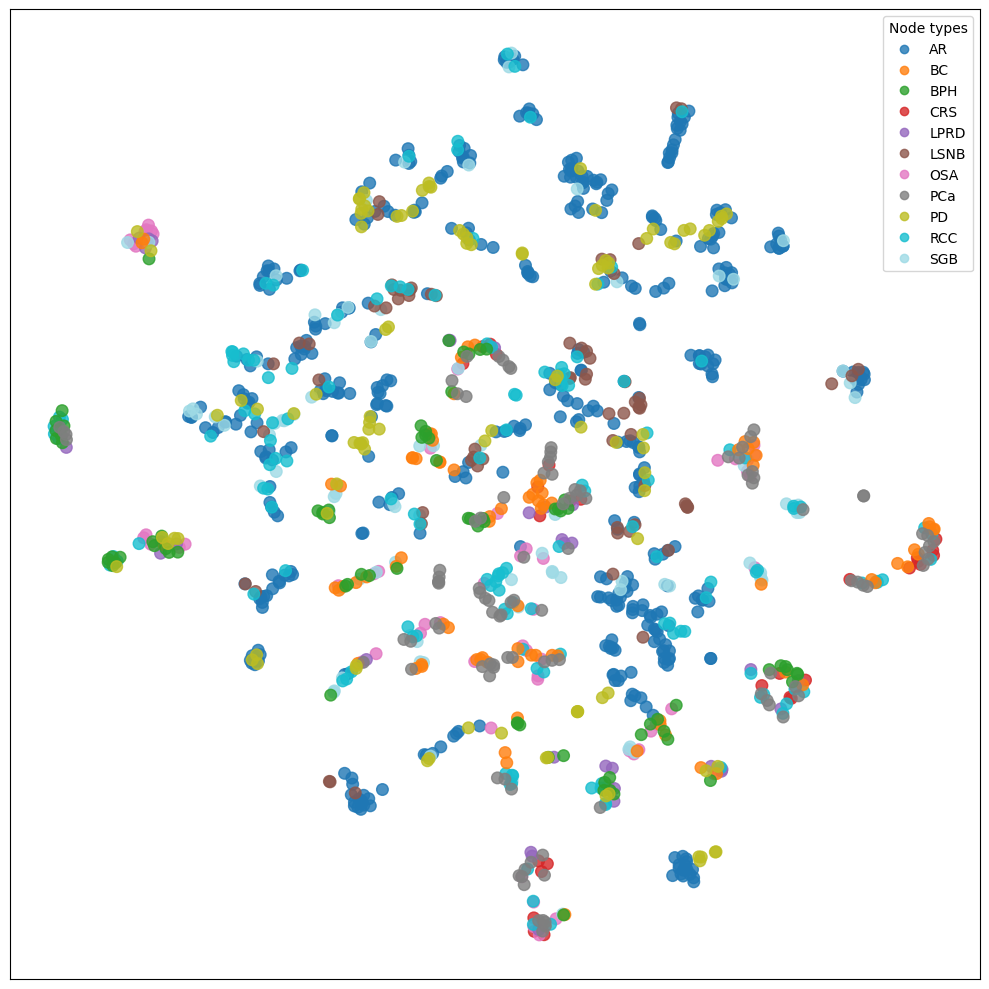

In [109]:
# Vizualization
model.eval()
out, z = model(data.x, data.edge_index)

visualize(z, data.y, groups_id)

In [110]:
# Train

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)#, weight_decay=5e-4)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []
epochs = 1000

# Training loop
pbar = tqdm(range(1, epochs + 1))
for epoch in pbar:
    # Mode train
    model.train()

    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    out, z = model(data.x, data.edge_index)

    # Calculate loss function
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    # Calculate accuracy
    acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    # Store data for animations
    embeddings.append(z)
    losses.append(loss.item())
    accuracies.append(acc)
    outputs.append(z.argmax(dim=1))

    # Print metrics
    pbar.set_description(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%")

    # Print metrics every 10 epochs
    """ if epoch % 10 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%") """

Epoch   1 | Loss: 2.42 | Acc: 4.81%:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1000 | Loss: 0.59 | Acc: 78.76%: 100%|██████████| 1000/1000 [00:21<00:00, 46.28it/s]


In [114]:
# Model evaluation
model.eval()
out, z = model(data.x, data.edge_index)
acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
print(f"Acc: {acc*100:.2f}%")

Acc: 42.40%


In [115]:
# Get node embeddings
print(z.shape)
z

torch.Size([1248, 64])


tensor([[ 0.5101,  0.7468, -0.3353,  ...,  0.9929, -0.2484, -0.1723],
        [ 0.3351,  0.5700, -0.1659,  ...,  0.9026,  0.4004,  0.0522],
        [ 0.4299,  0.8839, -0.3769,  ...,  1.0752, -0.3211, -0.1743],
        ...,
        [ 0.4819, -0.1339,  0.2313,  ...,  0.9310,  0.7738, -0.1695],
        [ 0.5106,  0.7165, -0.3328,  ...,  1.0944, -0.3711, -0.2482],
        [ 0.3428,  0.2047,  0.0437,  ...,  0.8590,  0.5719, -0.0031]],
       grad_fn=<EluBackward0>)

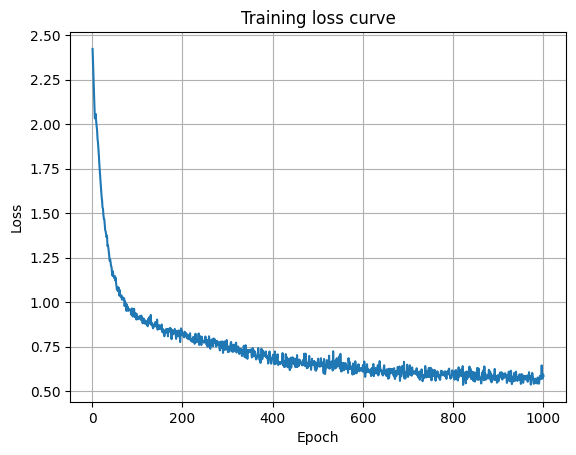

In [116]:
# Plot loss curve
plt.figure()
plt.plot(range(1, epochs + 1), losses, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training loss curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

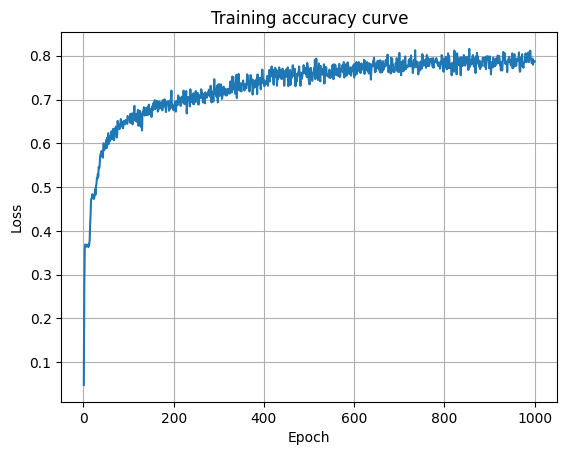

In [117]:
# Plot accuracy curve
plt.figure()
plt.plot(range(1, epochs + 1), accuracies, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training accuracy curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

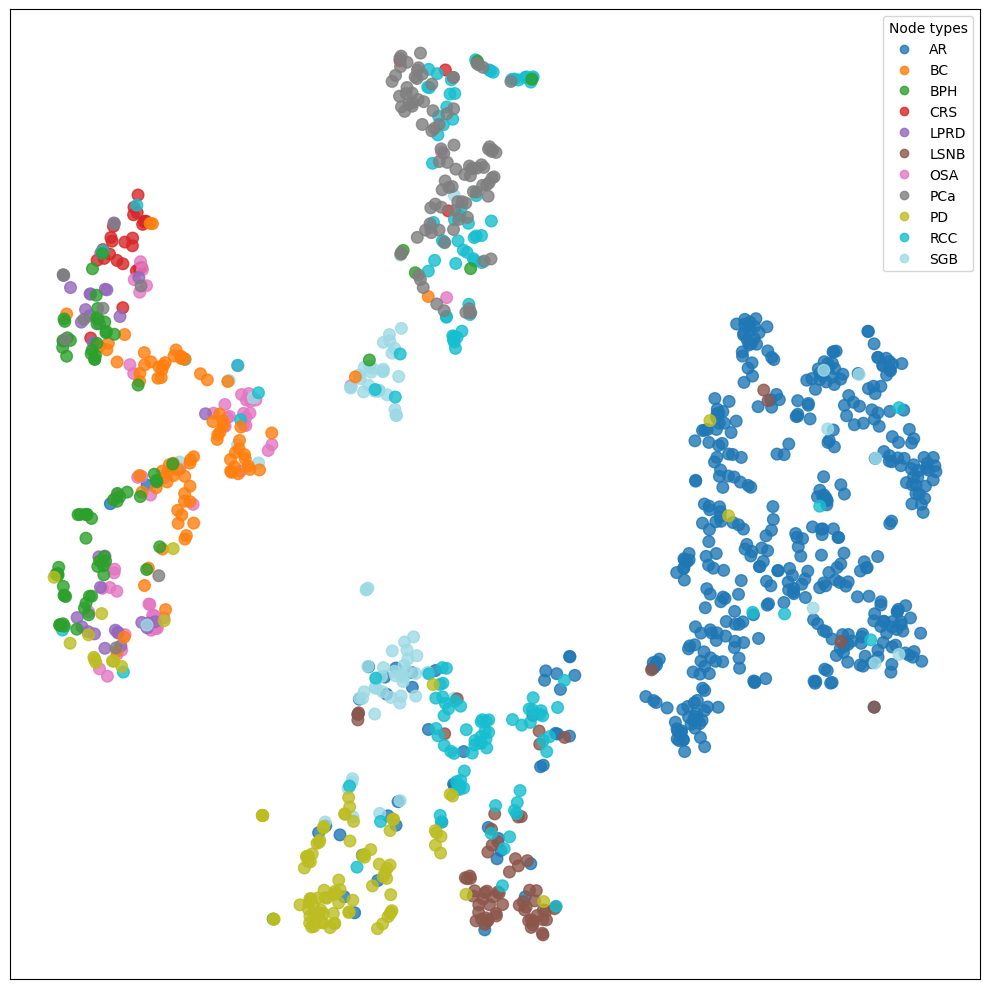

In [118]:
visualize(z, data.y, groups_id)